# 1. Libraries

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.tree import export_graphviz
from sklearn import tree
from IPython.display import Image  
from io import StringIO
import pydotplus
import torch
import torch.nn as nn

# 2. Data Collection

In [2]:
# Load datasets into pandas DataFrames
redurl = 'https://raw.githubusercontent.com/ccscaiado/MLRepo/main/Assignment%202%20Datasets/Wine%20Quality/winequality-red.csv'
redwinedata = pd.read_csv(redurl, header=0, sep=';')
whiteurl = 'https://raw.githubusercontent.com/ccscaiado/MLRepo/main/Assignment%202%20Datasets/Wine%20Quality/winequality-white.csv'
whitewinedata = pd.read_csv(whiteurl, header=0, sep=';')

In [3]:
# Check row number and column number of the datasets
print("Red wine data shape:", redwinedata.shape)
print("White wine data shape:", whitewinedata.shape)

Red wine data shape: (1599, 12)
White wine data shape: (4898, 12)


In [4]:
# Inspect the first few rows of the datasets
print("Red Wine Data:")
print(redwinedata.head())
print("\nWhite Wine Data:")
print(whitewinedata.head())

Red Wine Data:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2    

# 3. Data Cleaning & Preprocessing

In [5]:
# Check data types and dimension
print("\nRed Wine Data Info:")
print(redwinedata.info())
print("\nWhite Wine Data Info:")
print(whitewinedata.info())


Red Wine Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

White Wine Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Dat

In [6]:
# Adding a categorical variable
redwinedata['type'] = 'red'
whitewinedata['type'] = 'white'

# Combining 2 datasets
winedata = pd.concat([redwinedata, whitewinedata], axis=0, ignore_index=True)

# Print the first 5 rows
winedata.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [7]:
# Reheck data types and dimension of the combined dataset
winedata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [8]:
# Check for missing values
winedata.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

# 4. Exploratory Data Analysis

In [9]:
# Set size for all following plots
plt.figure(figsize=(12, 8), layout='constrained')

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

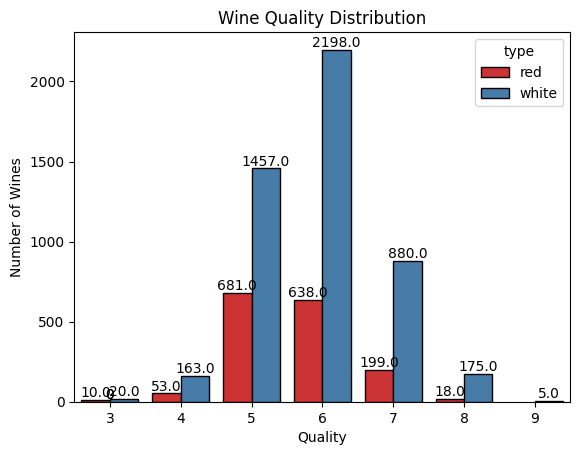

In [10]:
# Assess Wine Quality Distribution using a count plot
sns.countplot(data = winedata, x = "quality", hue = "type", palette = "Set1", edgecolor = "black")

# Set title and labels
plt.title("Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Number of Wines")
# Show numbers on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

Medium-quality wines account for the largest proportion here

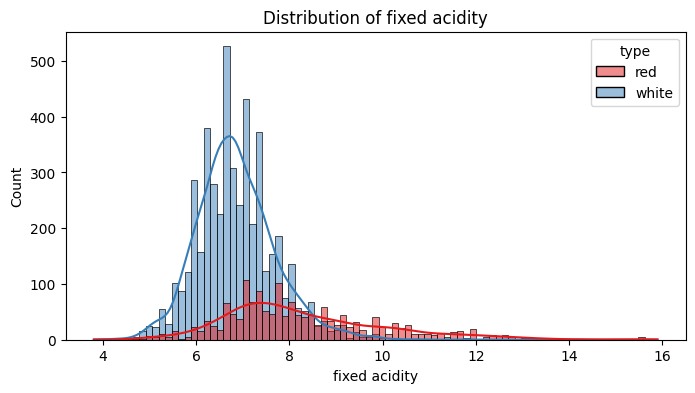

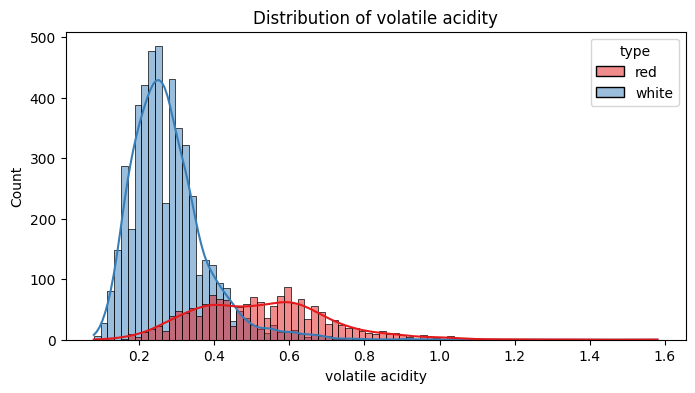

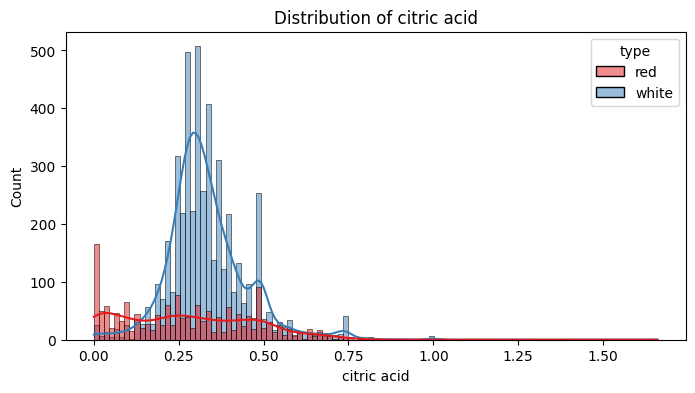

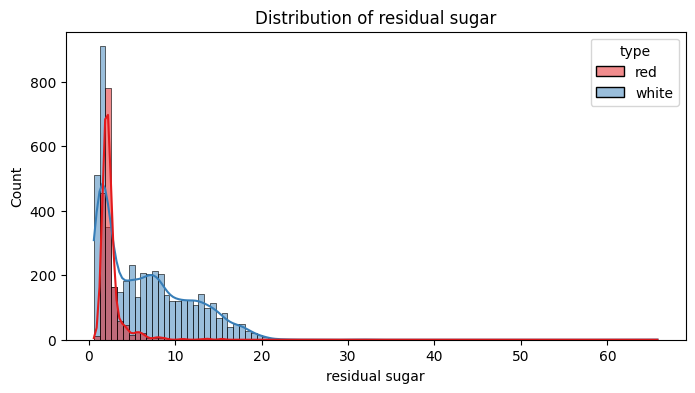

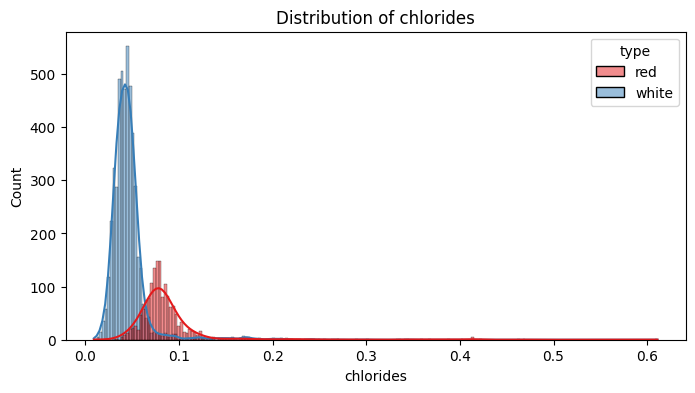

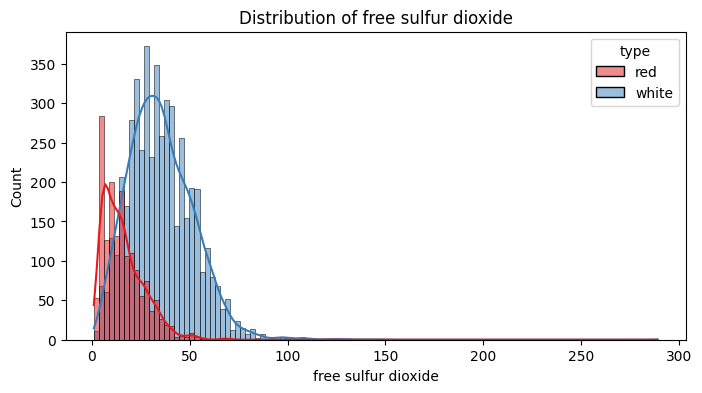

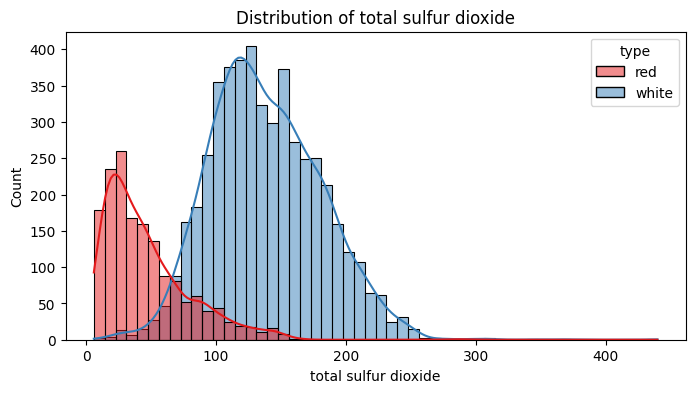

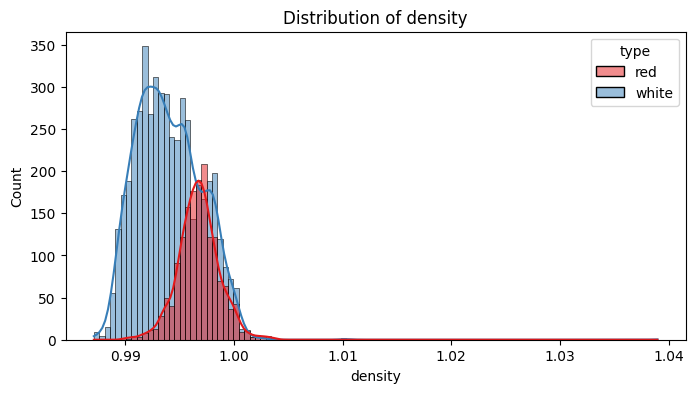

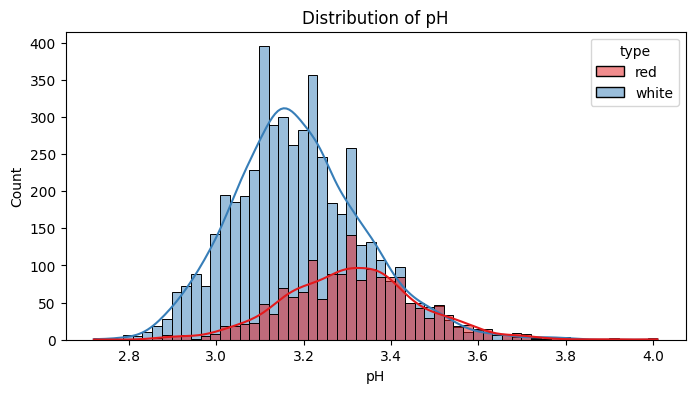

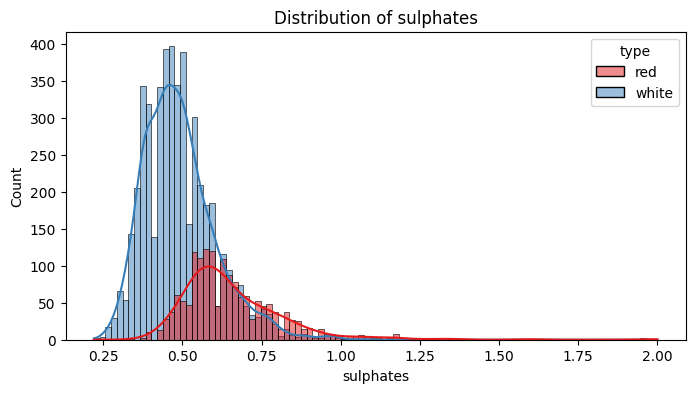

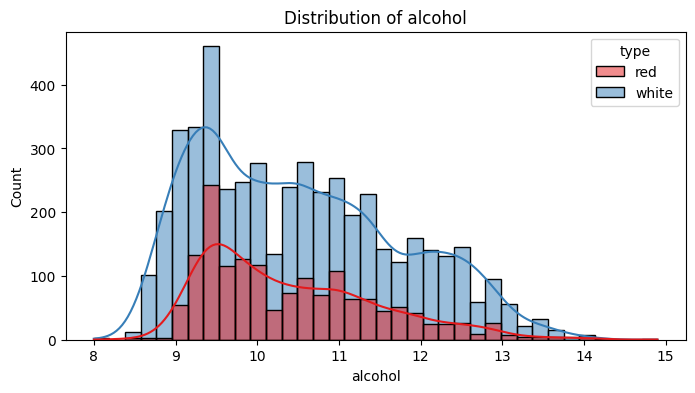

In [11]:
# Assess feature distributions using histograms
features = winedata.columns[:-2]  # Exclude 'quality' and 'type'
for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=winedata, x=feature, hue="type", kde=True, palette="Set1", edgecolor="black")
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()

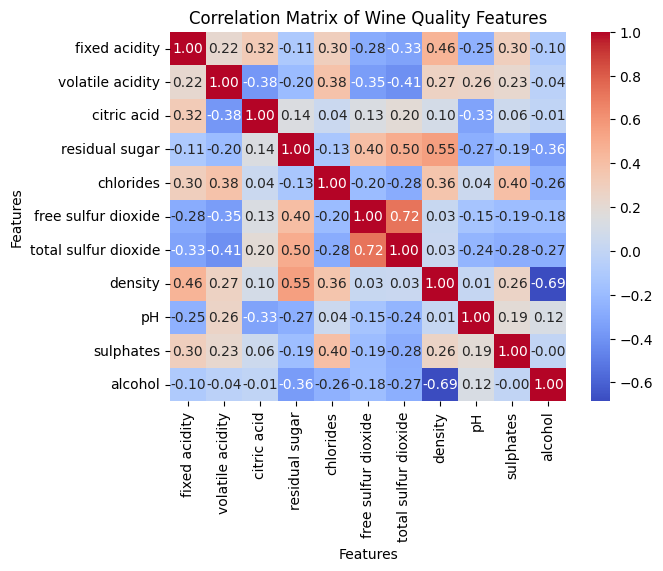

In [12]:
# Remove unnecessary columns for correlation analysis
numeric_data = winedata.select_dtypes(include=['float64', 'int64']).drop(columns=['quality'])

# Calculate and visualize the correlation matrix
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Wine Quality Features")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()


# 5. Feature Engineering & Selection

In [13]:
# Create a new column 'quality_label' based on the 'quality' column
def quality_label(quality):
    if quality <= 4:
        return 0
    elif quality <= 6:
        return 1
    else:
        return 2

In [14]:
# Apply the function to create the new column
winedata['quality_label'] = winedata['quality'].apply(quality_label)
winedata.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,1


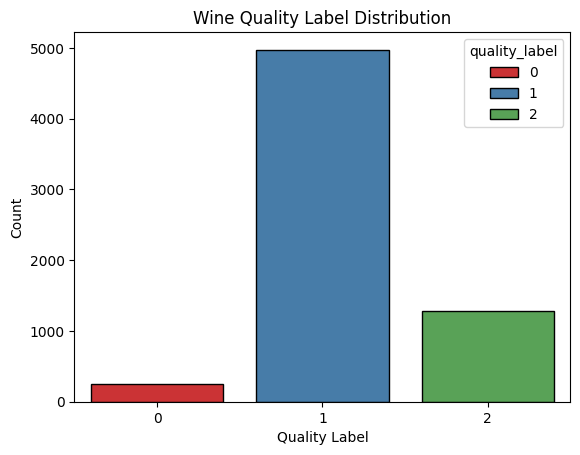

In [15]:
# Reheck the distribution of the new 'quality_label' column
sns.countplot(data=winedata, x='quality_label', hue='quality_label', palette='Set1', edgecolor='black')
plt.title("Wine Quality Label Distribution")
plt.xlabel("Quality Label")
plt.ylabel("Count")
plt.show()

Severe imbalance with "Medium" dominates in the dataset

In [16]:
# Drop unnecessary columns for modeling
winedata = winedata.drop(columns=['quality', 'type'])

In [17]:
winedata.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1


# 6. Modelling

## Data Preparation

In [18]:
# Set features and target variable
X = winedata.drop(columns=['quality_label'])
y = winedata['quality_label']

# Splitting data into training and testing with 80 and 20 percent respectively
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check the shape of the training and testing datasets
print("Training X data shape:", X_train.shape)
print("Training y data shape:", y_train.shape)
print("\nTesting X data shape:", X_test.shape)
print("Testing y data shape:", y_test.shape)

Training X data shape: (5197, 11)
Training y data shape: (5197,)

Testing X data shape: (1300, 11)
Testing y data shape: (1300,)


C:\Users\DELL\AppData\Local\Temp\ipykernel_11328\2845198245.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='Set1', edgecolor='black')
C:\Users\DELL\AppData\Local\Temp\ipykernel_11328\2845198245.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, palette='Set1', edgecolor='black')


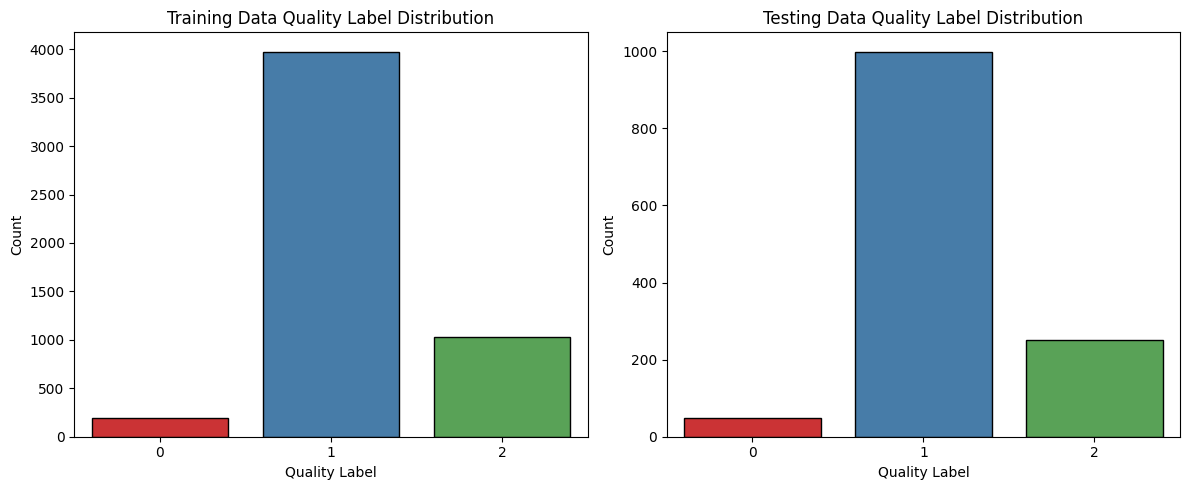

In [30]:
# Category distribution in training and testing datasets
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='Set1', edgecolor='black')
plt.title("Training Data Quality Label Distribution")
plt.xlabel("Quality Label")
plt.ylabel("Count")
plt.subplot(1, 2, 2)
sns.countplot(x=y_test, palette='Set1', edgecolor='black')
plt.title("Testing Data Quality Label Distribution")
plt.xlabel("Quality Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [20]:
# Define a function to compute metrics
import seaborn as sns
import matplotlib.pyplot as plt

def get_metrics(real_score, prediction):
    
    # Plot the confusion matrix
    cm = confusion_matrix(real_score, prediction)
    
    sns.heatmap(cm.T, square = True, annot = True, fmt = 'd', xticklabels = ["0", "1", "2"], yticklabels = ["0", "1", "2"],
           cmap = 'Reds')
    
    plt.xlabel('True Label')
    
    plt.ylabel('Predicted Label')
    
    plt.show()
    
    print("Accuracy:" , accuracy_score(real_score, prediction))
    print("F1-score:" , f1_score(real_score, prediction, average='macro')) # Get average score for all classes
    print("Precision:" , precision_score(real_score, prediction, average='macro')) # Get average score for all classes
    print("Recall:" , recall_score(real_score, prediction, average='macro')) # Get average score for all classes
    print("\nClassification performance:\n" , classification_report(real_score, prediction))

## Decision Tree

### Model Building 

In [ ]:
# Create the decision tree classifier model
clf = tree.DecisionTreeClassifier(random_state=42)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

# Predict the response for test dataset
y_pred = clf.predict(X_test)

### Model Validation

In [ ]:
# Print the first 10 predictions and ground truth values
print("Predicted:", y_pred.tolist()[0:10]) # Print the first 10 predictions
print("Ground truth:", y_test.tolist()[0:10]) # Print the first 10 ground truth values

Predicted: [1, 1, 2, 1, 1, 1, 1, 1, 1, 1]
Ground truth: [2, 1, 2, 1, 1, 1, 1, 1, 1, 2]


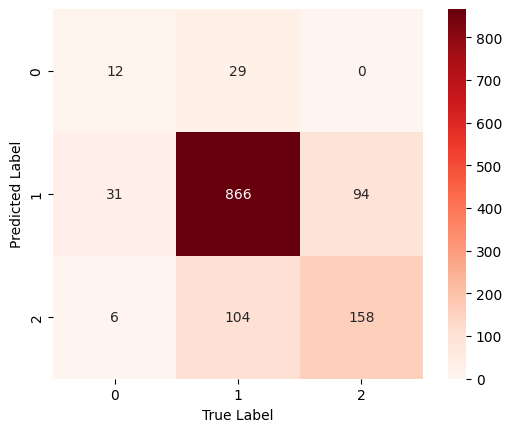

Accuracy: 0.796923076923077
F1-score: 0.5815702443843147
Precision: 0.5853666495608885
Recall: 0.5795829843448891

Classification performance:
               precision    recall  f1-score   support

           0       0.29      0.24      0.27        49
           1       0.87      0.87      0.87       999
           2       0.59      0.63      0.61       252

    accuracy                           0.80      1300
   macro avg       0.59      0.58      0.58      1300
weighted avg       0.80      0.80      0.80      1300



In [23]:
# Evaluate the model performance
get_metrics(y_test, y_pred)

## Neural Network

### Data Scaling

In [24]:
# Data Scaling
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train.astype(float))
X_test_s  = scaler.transform(X_test.astype(float))

In [25]:
# Turning data into tensor
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)  # 0-indexed
y_test_t  = torch.tensor(y_test.values,  dtype=torch.long)

### Building Model

In [26]:
import numpy as np
# Set a seed for torch random operations
torch.manual_seed(42)
n_features = X_train_t.shape[1]

model = nn.Sequential(
    nn.Linear(n_features, 100), nn.ReLU(),
    nn.Linear(100, 50),         nn.ReLU(),
    nn.Linear(50, 20),          nn.ReLU(),
    nn.Linear(20, 3)            # 3 output classes
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Define epochs
epochs = 2000

# Loop through each epoch
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    out = model(X_train_t)
    loss = criterion(out, y_train_t)
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        with torch.no_grad():
            acc = (out.argmax(1) == y_train_t).float().mean().item()
        print(f"Epoch {epoch:4d} | Loss {loss.item():.4f} | Train acc {acc:.4f}")

Epoch  100 | Loss 0.5176 | Train acc 0.7887
Epoch  200 | Loss 0.4678 | Train acc 0.8020
Epoch  300 | Loss 0.4462 | Train acc 0.8078
Epoch  400 | Loss 0.4360 | Train acc 0.8149
Epoch  500 | Loss 0.4295 | Train acc 0.8164
Epoch  600 | Loss 0.4170 | Train acc 0.8236
Epoch  700 | Loss 0.4166 | Train acc 0.8249
Epoch  800 | Loss 0.4011 | Train acc 0.8345
Epoch  900 | Loss 0.3897 | Train acc 0.8368
Epoch 1000 | Loss 0.4156 | Train acc 0.8197
Epoch 1100 | Loss 0.4007 | Train acc 0.8322
Epoch 1200 | Loss 0.3956 | Train acc 0.8334
Epoch 1300 | Loss 0.3917 | Train acc 0.8355
Epoch 1400 | Loss 0.4003 | Train acc 0.8336
Epoch 1500 | Loss 0.3871 | Train acc 0.8372
Epoch 1600 | Loss 0.3907 | Train acc 0.8343
Epoch 1700 | Loss 0.3776 | Train acc 0.8432
Epoch 1800 | Loss 0.3725 | Train acc 0.8484
Epoch 1900 | Loss 0.3790 | Train acc 0.8453
Epoch 2000 | Loss 0.3806 | Train acc 0.8361


### Validation

In [27]:
# Prediction on new data
model.eval()
with torch.no_grad():
    nn_pred = model(X_test_t).argmax(1).numpy()

In [28]:
# Print the first 10 predictions and ground truth values
print("Predicted:", nn_pred.tolist()[0:10]) # Print the first 10 predictions
print("Ground truth:", y_test.tolist()[0:10]) # Print the first 10 ground truth values

Predicted: [1, 1, 2, 1, 1, 1, 1, 1, 1, 2]
Ground truth: [2, 1, 2, 1, 1, 1, 1, 1, 1, 2]


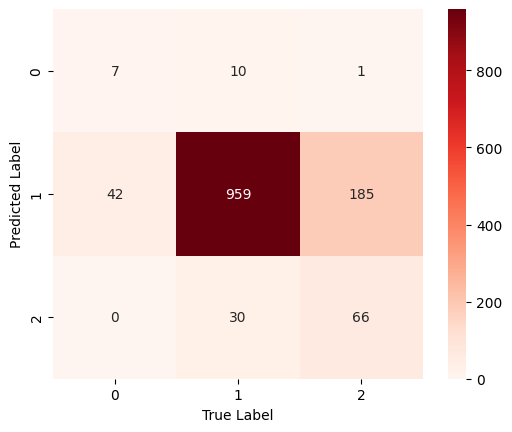

Accuracy: 0.7938461538461539
F1-score: 0.4886895907898368
Precision: 0.628329742052339
Recall: 0.45490728824062154

Classification performance:
               precision    recall  f1-score   support

           0       0.39      0.14      0.21        49
           1       0.81      0.96      0.88       999
           2       0.69      0.26      0.38       252

    accuracy                           0.79      1300
   macro avg       0.63      0.45      0.49      1300
weighted avg       0.77      0.79      0.76      1300



In [29]:
# Confusion matrix and metrics for the neural network model
get_metrics(y_test, nn_pred)